# 数据处理

## 1. 构建弱框标注

test visualization of annotation GT

In [1]:
from utils import parse_voc_xml, draw_boxes
from PIL import Image

class_map_encoding = {'leuko' : 0, 'eryth' : 1, 'mycete' : 2}
class_map_decoding = {v: k for k, v in class_map_encoding.items()}
xml_path = 'test_images/nh00001.xml'
image_path = 'test_images/nh00001.jpg'

image_info, boxes = parse_voc_xml(xml_path, class_map_encoding)
image = Image.open(image_path)
image = draw_boxes(image, boxes, class_map_decoding)
image.show()
for k, v in image_info.items():
    print(f'{k}: {v}')

width: 800
height: 600
depth: 3


build weak boxes from GT

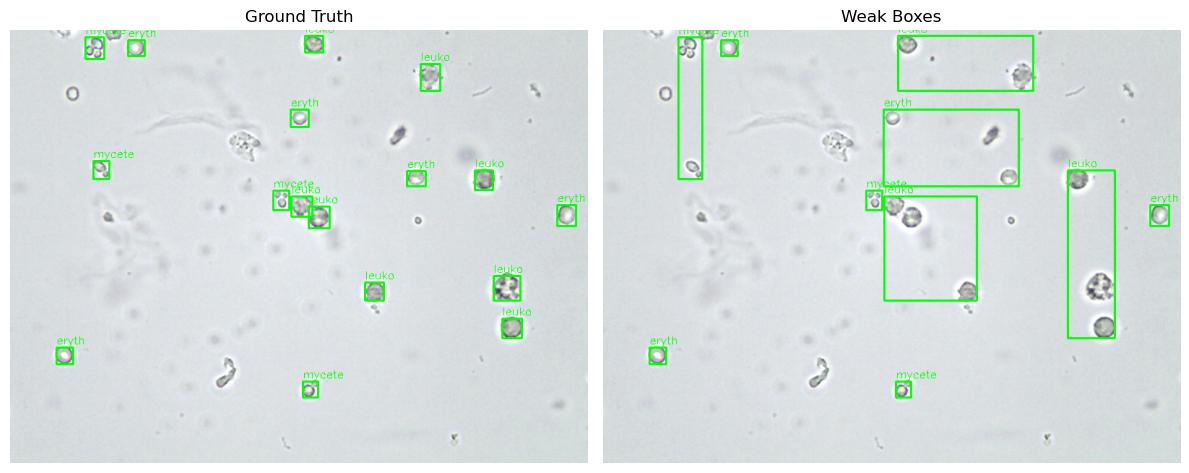

width: 800
height: 600
depth: 3


In [3]:
from utils import build_weak_boxes, parse_voc_xml, draw_boxes
from typing import List, Tuple
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np

class_map_encoding = {'leuko' : 0, 'eryth' : 1, 'mycete' : 2}
class_map_decoding = {v: k for k, v in class_map_encoding.items()}
xml_path = 'test_images/nh00001.xml'
image_path = 'test_images/nh00001.jpg'

image = Image.open(image_path)
image_info, gt = parse_voc_xml(xml_path, class_map_encoding)
wb = build_weak_boxes(gt, purity_mode="center")
image_gt = draw_boxes(image, gt, class_map_decoding)
image_wb = draw_boxes(image, wb, class_map_decoding)

# Visualize GT and Weak Boxes side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Ground Truth visualization
axes[0].imshow(np.array(image_gt))
axes[0].set_title("Ground Truth")
axes[0].axis("off")

# Weak Boxes visualization
axes[1].imshow(np.array(image_wb))
axes[1].set_title("Weak Boxes")
axes[1].axis("off")

plt.tight_layout()
plt.show()

for k, v in image_info.items():
    print(f'{k}: {v}')